In [1]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
import json
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    # LabelEncoder,
)
from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
)

import joblib

In [3]:
df = pd.read_csv('House_Rent_Dataset.csv')

In [4]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [6]:
df.nunique()

Posted On              81
BHK                     6
Rent                  243
Size                  615
Floor                 480
Area Type               3
Area Locality        2235
City                    6
Furnishing Status       3
Tenant Preferred        3
Bathroom                8
Point of Contact        3
dtype: int64

In [7]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [8]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [9]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [10]:
# key = "Bathroom"
# Q1 = df[key].quantile(0.25)
# Q3 = df[key].quantile(0.75)
# IQR = Q3 - Q1
# alt_sinir = Q1 - 5 * IQR
# ust_sinir = Q3 + 5 * IQR

# df[((df[key] >= alt_sinir) & (df[key] >= ust_sinir))]

In [11]:
df['Room Size Ratio'] =  df['Size'] / ((df['Bathroom'] + df['BHK']))

In [12]:
df['Size Rent Ratio'] =  df['Rent'] / df['Size']

In [13]:
df.describe()

,BHK,Rent,Size,Bathroom,Room Size Ratio,Size Rent Ratio
count,4746.000000,4.746000e+03,4746.000000,4746.000000,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866,232.730299,39.257087
std,0.832256,7.810641e+04,634.202328,0.884532,88.621472,59.855230
min,1.000000,1.200000e+03,10.000000,1.000000,1.666667,0.571429
25%,2.000000,1.000000e+04,550.000000,1.000000,183.333333,13.333333
50%,2.000000,1.600000e+04,850.000000,2.000000,225.000000,20.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000,276.562500,42.005986
max,6.000000,3.500000e+06,8000.000000,10.000000,1080.000000,1500.000000


In [14]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Room Size Ratio,Size Rent Ratio
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,275.000000,9.090909
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,266.666667,25.000000
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,333.333333,17.000000
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,266.666667,12.500000
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,283.333333,8.823529


In [15]:
# df[~(df['Rent'] <= df['Rent'].quantile(0.99)) & (df['Size'] <= df['Size'].quantile(0.99))]

In [16]:
df = df[
    (
        (df["Room Size Ratio"] <= df["Room Size Ratio"].quantile(0.999))
        & (df["Rent"] <= df["Rent"].quantile(0.999))
    )
]

In [17]:
label_encoder = LabelEncoder()
df["Area Type (Encoded)"] = label_encoder.fit_transform(df["Area Type"])
df["City (Encoded)"] = label_encoder.fit_transform(df["City"])
# df["Area Locality (Encoded)"] = label_encoder.fit_transform(df["Area Locality"])
df["Furnishing Status (Encoded)"] = label_encoder.fit_transform(df["Furnishing Status"])

In [18]:
def feature_floor_split(r):
    if ' out of ' in r['Floor']:
        floor, max_floors = r['Floor'].split(' out of ')
        return [
            -1 if 'Basement' in floor else int(floor)
            , int(max_floors)
        ]
    # This accounts for the values where instead of having a floor like "1 out of 3", it just has "1".
    return [int(r['Floor'].split(' out of ')[0]), None]

def feature_is_basement(r: pd.core.series.Series) -> str:
    if 'Basement' in r['Floor']:
        return 1
    return 0

# Replace all instances of "Ground" with 0
df['Floor'] = df['Floor'].str.replace('Ground', '0')

df['Is Basement'] = df.apply(lambda row: feature_is_basement(row), axis=1)
df['Floor Number'] = df.apply(lambda row: feature_floor_split(row)[0], axis=1)
df['Building Floors'] = df.apply(lambda row: feature_floor_split(row)[1], axis=1)

df

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Room Size Ratio,Size Rent Ratio,Area Type (Encoded),City (Encoded),Furnishing Status (Encoded),Is Basement,Floor Number,Building Floors
0,2022-05-18,2,10000,1100,0 out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,275.000000,9.090909,2,4,2,0,0,2.0
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,266.666667,25.000000,2,4,1,0,1,3.0
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,333.333333,17.000000,2,4,1,0,1,3.0
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,266.666667,12.500000,2,4,2,0,1,2.0
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,283.333333,8.823529,1,4,2,0,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,250.000000,15.000000,1,3,1,0,3,5.0
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,333.333333,14.500000,2,3,1,0,1,4.0
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,291.666667,20.000000,1,3,1,0,3,5.0
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,300.000000,30.000000,1,3,1,0,23,34.0


In [19]:
df = df.drop(columns="Posted On")

In [20]:
df

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Room Size Ratio,Size Rent Ratio,Area Type (Encoded),City (Encoded),Furnishing Status (Encoded),Is Basement,Floor Number,Building Floors
0,2,10000,1100,0 out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,275.000000,9.090909,2,4,2,0,0,2.0
1,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,266.666667,25.000000,2,4,1,0,1,3.0
2,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,333.333333,17.000000,2,4,1,0,1,3.0
3,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,266.666667,12.500000,2,4,2,0,1,2.0
4,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,283.333333,8.823529,1,4,2,0,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,250.000000,15.000000,1,3,1,0,3,5.0
4742,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,333.333333,14.500000,2,3,1,0,1,4.0
4743,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,291.666667,20.000000,1,3,1,0,3,5.0
4744,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,300.000000,30.000000,1,3,1,0,23,34.0


In [21]:
df = df.dropna()

In [22]:
Counter(df["Furnishing Status (Encoded)"])

Counter({1: 2244, 2: 1812, 0: 676})

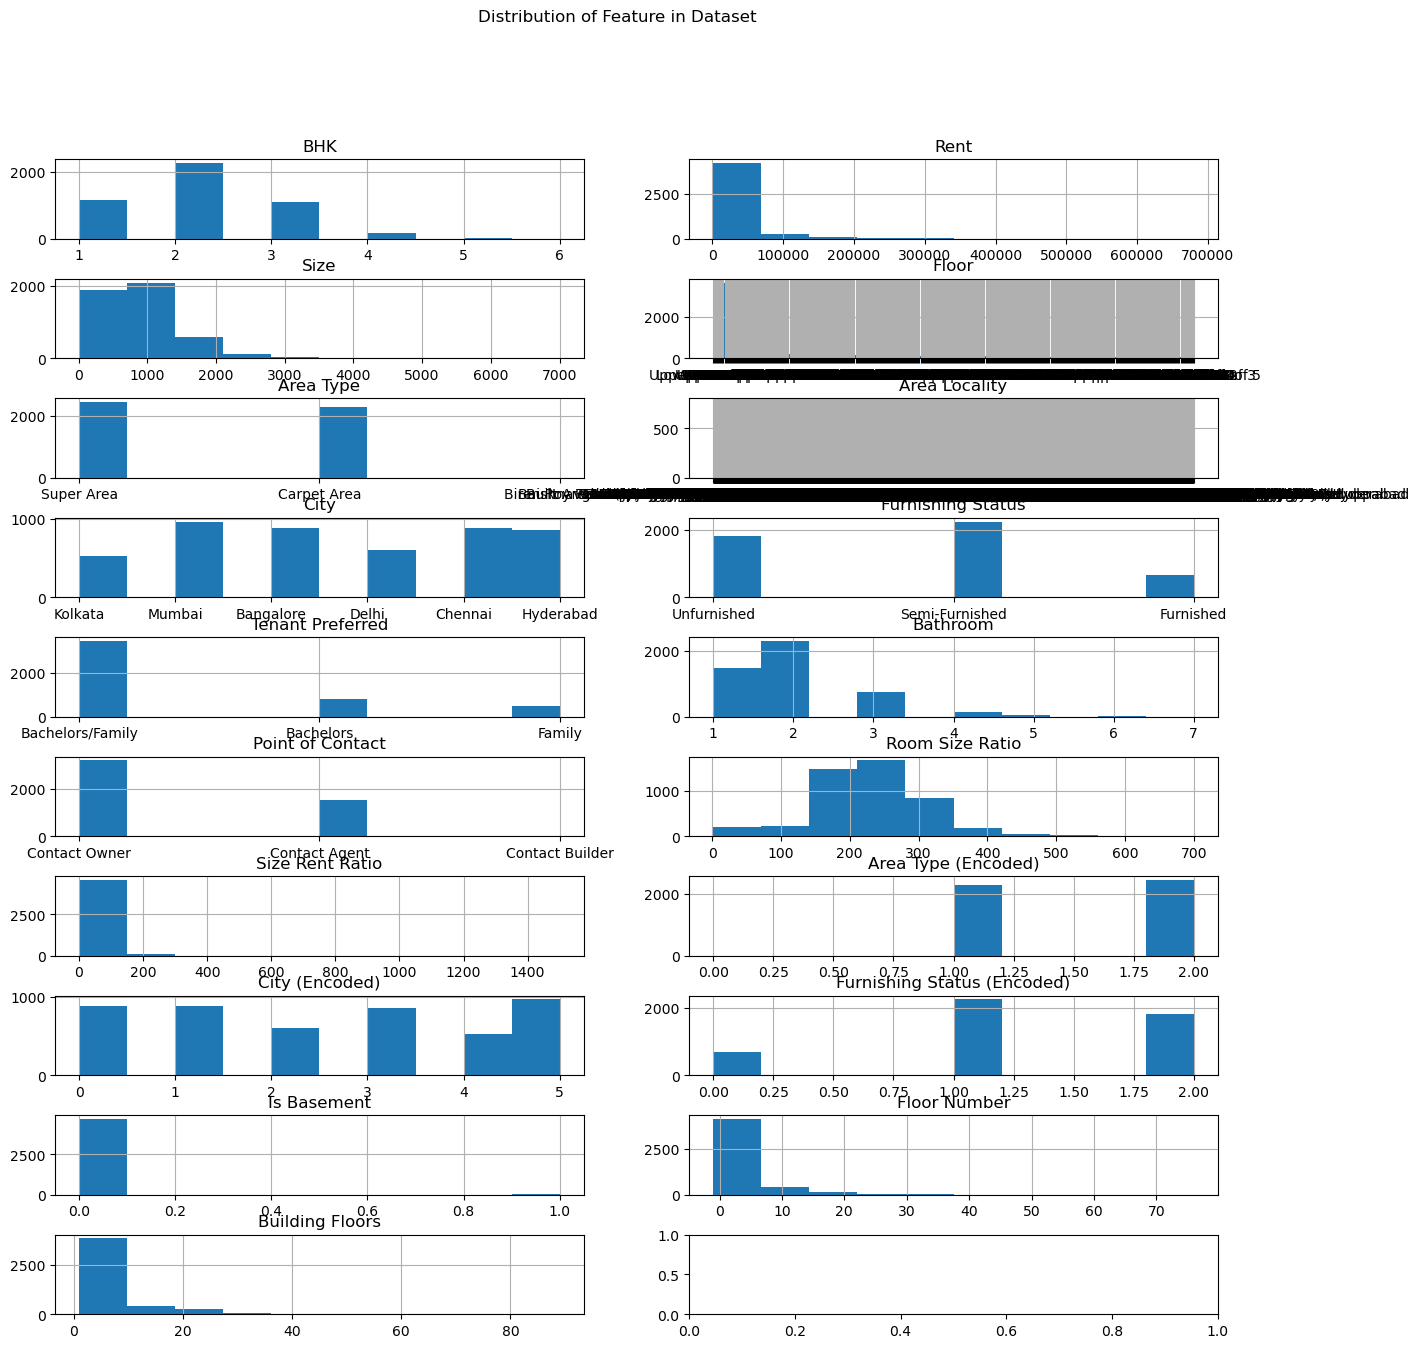

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Room Size Ratio,Size Rent Ratio,Area Type (Encoded),City (Encoded),Furnishing Status (Encoded),Is Basement,Floor Number,Building Floors
4741,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,250.000000,15.0,1,3,1,0,3,5.0
4742,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,333.333333,14.5,2,3,1,0,1,4.0
4743,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,291.666667,20.0,1,3,1,0,3,5.0
4744,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,300.000000,30.0,1,3,1,0,23,34.0
4745,2,15000,1000,4 out of 5,Carpet Area,Suchitra Circle,Hyderabad,Unfurnished,Bachelors,2,Contact Owner,250.000000,15.0,1,3,2,0,4,5.0


In [23]:
fig, axes = plt.subplots(
    nrows=int(np.ceil(len(df.columns) / 2)), ncols=2, figsize=(15, 15)
)
fig.subplots_adjust(hspace=0.5)
fig.suptitle("Distribution of Feature in Dataset")

# Generate histograms
for ax, column in zip(axes.flatten(), df.columns):
    ax.set_title(f"{column}")
    df[column].hist(ax=ax)

plt.show()

df.tail()

In [24]:
df["Tenant Preferred (Bachelors)"] = df["Tenant Preferred"].str.contains("Bachelors")
df["Tenant Preferred (Family)"] = df["Tenant Preferred"].str.contains("Family")

df["Point of Contact (Contact Builder)"] = df["Point of Contact"] == 'Contact Builder'
df["Point of Contact (Contact Owner)"] = df["Point of Contact"] == 'Contact Owner'
df["Point of Contact (Contact Agent)"] = df["Point of Contact"] == 'Contact Agent'



C:\Users\berkd\AppData\Local\Temp\ipykernel_27072\212349547.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Tenant Preferred (Bachelors)"] = df["Tenant Preferred"].str.contains("Bachelors")
C:\Users\berkd\AppData\Local\Temp\ipykernel_27072\212349547.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Tenant Preferred (Family)"] = df["Tenant Preferred"].str.contains("Family")
C:\Users\berkd\AppData\Local\Temp\ipykernel_27072\212349547.py:4: SettingWithCopyWarning: 
A value is trying to be set on 

In [25]:
df.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact',
       'Room Size Ratio', 'Size Rent Ratio', 'Area Type (Encoded)',
       'City (Encoded)', 'Furnishing Status (Encoded)', 'Is Basement',
       'Floor Number', 'Building Floors', 'Tenant Preferred (Bachelors)',
       'Tenant Preferred (Family)', 'Point of Contact (Contact Builder)',
       'Point of Contact (Contact Owner)', 'Point of Contact (Contact Agent)'],
      dtype='object')

In [26]:
clean_df = df.copy()

In [27]:
clean_df = clean_df.drop(
    columns=["Tenant Preferred", "Point of Contact", "Furnishing Status", "Floor", "Area Type", "Area Locality","City", "Size Rent Ratio"]
)

In [28]:
clean_df.columns

Index(['BHK', 'Rent', 'Size', 'Bathroom', 'Room Size Ratio',
       'Area Type (Encoded)', 'City (Encoded)', 'Furnishing Status (Encoded)',
       'Is Basement', 'Floor Number', 'Building Floors',
       'Tenant Preferred (Bachelors)', 'Tenant Preferred (Family)',
       'Point of Contact (Contact Builder)',
       'Point of Contact (Contact Owner)', 'Point of Contact (Contact Agent)'],
      dtype='object')

In [29]:
clean_df = clean_df.replace({True: 1, False: 0})

C:\Users\berkd\AppData\Local\Temp\ipykernel_27072\2959579157.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clean_df = clean_df.replace({True: 1, False: 0})


In [30]:
clean_df

,BHK,Rent,Size,Bathroom,Room Size Ratio,Area Type (Encoded),City (Encoded),Furnishing Status (Encoded),Is Basement,Floor Number,Building Floors,Tenant Preferred (Bachelors),Tenant Preferred (Family),Point of Contact (Contact Builder),Point of Contact (Contact Owner),Point of Contact (Contact Agent)
0,2,10000,1100,2,275.000000,2,4,2,0,0,2.0,1,1,0,1,0
1,2,20000,800,1,266.666667,2,4,1,0,1,3.0,1,1,0,1,0
2,2,17000,1000,1,333.333333,2,4,1,0,1,3.0,1,1,0,1,0
3,2,10000,800,1,266.666667,2,4,2,0,1,2.0,1,1,0,1,0
4,2,7500,850,1,283.333333,1,4,2,0,1,2.0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000,1000,2,250.000000,1,3,1,0,3,5.0,1,1,0,1,0
4742,3,29000,2000,3,333.333333,2,3,1,0,1,4.0,1,1,0,1,0
4743,3,35000,1750,3,291.666667,1,3,1,0,3,5.0,1,1,0,0,1
4744,3,45000,1500,2,300.000000,1,3,1,0,23,34.0,0,1,0,0,1


In [31]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4732 entries, 0 to 4745
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   BHK                                 4732 non-null   int64  
 1   Rent                                4732 non-null   int64  
 2   Size                                4732 non-null   int64  
 3   Bathroom                            4732 non-null   int64  
 4   Room Size Ratio                     4732 non-null   float64
 5   Area Type (Encoded)                 4732 non-null   int64  
 6   City (Encoded)                      4732 non-null   int64  
 7   Furnishing Status (Encoded)         4732 non-null   int64  
 8   Is Basement                         4732 non-null   int64  
 9   Floor Number                        4732 non-null   int64  
 10  Building Floors                     4732 non-null   float64
 11  Tenant Preferred (Bachelors)        4732 non-nul

# Train

In [32]:
regressor = RandomForestRegressor(n_estimators=100, random_state=31)

y = clean_df["Rent"]
X = clean_df.drop("Rent", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = KFold(n_splits=10, shuffle=True, random_state=69)

mae_scores = cross_val_score(
    regressor, X_scaled, y, scoring="neg_mean_absolute_error", cv=kf
)
mse_scores = cross_val_score(
    regressor, X_scaled, y, scoring="neg_mean_squared_error", cv=kf
)
rmse_scores = cross_val_score(
    regressor, X_scaled, y, scoring="neg_root_mean_squared_error", cv=kf
)
r2_scores = cross_val_score(regressor, X_scaled, y, scoring="r2", cv=kf)

results = {
    "Random Forest": {
        "MAE": "%.4f" % np.mean(-mae_scores),
        "MSE": "%.4f" % np.mean(-mse_scores),
        "RMSE": "%.4f" % np.mean(-rmse_scores),
        "R2": "%.4f" % np.mean(r2_scores),
    }
}

print("Random Forest Model Performance:")
print("================================")
for metric, value in results["Random Forest"].items():
    print(f"{metric}: {value}")

print("\nStandard Deviations:")
print("MAE: ±%.4f" % np.std(-mae_scores))
print("MSE: ±%.4f" % np.std(-mse_scores))
print("RMSE: ±%.4f" % np.std(-rmse_scores))
print("R2: ±%.4f" % np.std(r2_scores))

Random Forest Model Performance:
MAE: 11074.0622
MSE: 772533173.6488
RMSE: 27374.8254
R2: 0.7149

Standard Deviations:
MAE: ±904.8226
MSE: ±263250216.3985
RMSE: ±4811.6639
R2: ±0.1020
